<p style="background-color:#AFB6B2;color:black;font-size:22px;text-align:center;border-radius:10px 10px;font-weight:bold;border:2px solid black;">Digit Recognizor with CNN <span style='font-size:28px; background-color:#AFB6B2 ;'></span></p>


<center><img src="https://github.com/Isharaneranjana/kaggle_gif/blob/main/Digit%20recognition.gif?raw=true"></center>

## <p style="background-color:#AFB6B2;color:black;font-size:20px;text-align:center;border-radius:10px 10px;"> Introduction 🔽</p>
<font size="4">The MNIST dataset is an acronym that stands for the Modified National Institute of Standards and Technology dataset.It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9.The task is to classify a given image of a handwritten digit into one of 10 classes representing integer values from 0 to 9, inclusively. </font>



In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings


/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
test_df = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')


In [4]:
train_df.shape

(42000, 785)

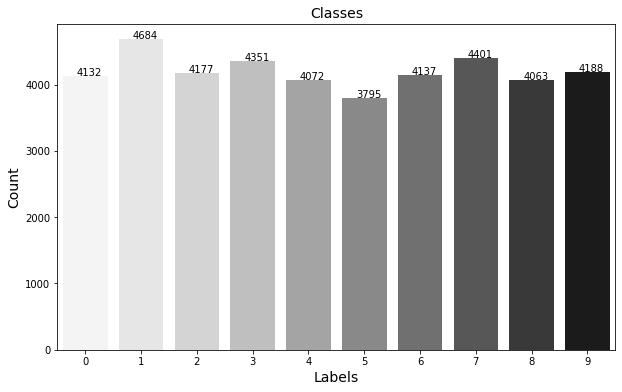

In [5]:
plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'label', data = train_df,palette="Greys")
plt.title('Classes', fontsize = 14)
plt.xlabel('Labels', fontsize = 14)
plt.ylabel('Count', fontsize = 14)
for p in ax.patches:
        ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.25, p.get_height() + 10))

In [6]:
y_train = train_df['label']
X_train = train_df.drop('label', axis=1)
x_train = X_train/255
test=test_df/255

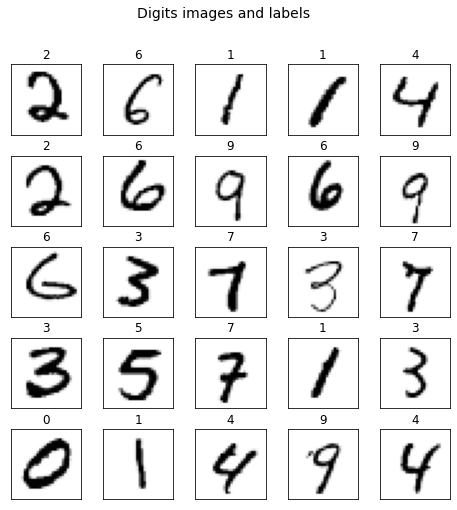

In [7]:
import random
fig, ax = plt.subplots(5, 5, figsize=(8, 8))
fig.suptitle('Digits images and labels', fontsize=14)
ax = ax.ravel()
for i in range(25):
    sample_n = random.randint(0, x_train.shape[0])
    ax[i].imshow(np.array(x_train.iloc[sample_n]).reshape(28, 28), cmap='Greys')
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
    ax[i].set_title(y_train[sample_n], fontsize = 12)

plt.subplots_adjust(hspace=0.3)

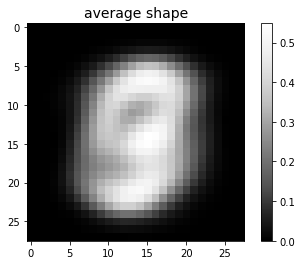

In [8]:
plt.imshow(np.array(x_train.mean()).reshape(28, 28), cmap='Greys_r')
plt.colorbar()
plt.title('average shape', {'fontsize': 14})
plt.show()

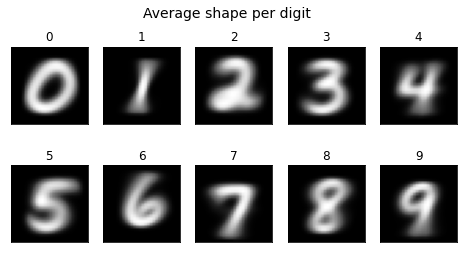

In [9]:
fig, ax = plt.subplots(2, 5, figsize=(8, 4))
fig.suptitle('Average shape per digit', fontsize=14)

ax = ax.ravel()

for i in range(10):
    ax[i].imshow(np.array(train_df[train_df['label'] == i].drop('label', axis=1).mean()).reshape(28, 28), cmap='Greys_r')
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
    ax[i].set_title(i, fontsize = 12)

In [10]:
x_train_array = np.array(x_train)
test_array = np.array(test)

In [11]:
x_train_array = x_train_array.reshape(42000, 28, 28, 1)
test_array = test_array.reshape(-1, 28, 28, 1)

In [12]:
import tensorflow as tf
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode="constant",
    
    horizontal_flip=False,
    vertical_flip=False,
    
    rotation_range=20,
    
    validation_split=0.2
)

In [13]:
datagen.fit(x_train_array)

In [14]:
from keras.utils import np_utils
y_train = np_utils.to_categorical(y_train)


In [15]:
warnings.filterwarnings("ignore")
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization

cnn1 = Sequential()
cnn1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
cnn1.add(BatchNormalization())

cnn1.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
cnn1.add(BatchNormalization())
cnn1.add(MaxPooling2D(pool_size=(2, 2)))
cnn1.add(Dropout(0.25))

cnn1.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn1.add(BatchNormalization())
cnn1.add(Dropout(0.25))

cnn1.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
cnn1.add(BatchNormalization())
cnn1.add(MaxPooling2D(pool_size=(2, 2)))
cnn1.add(Dropout(0.25))
cnn1.add(Flatten())

cnn1.add(Dense(512, activation='relu'))
cnn1.add(BatchNormalization())
cnn1.add(Dropout(0.5))

cnn1.add(Dense(128, activation='relu'))
cnn1.add(BatchNormalization())
cnn1.add(Dropout(0.5))

cnn1.add(Dense(10, activation='softmax'))

2022-11-20 01:32:29.431917: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-20 01:32:29.551380: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-20 01:32:29.552297: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-20 01:32:29.553432: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [16]:
cnn1.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

In [17]:
history = cnn1.fit(datagen.flow(x_train_array, y_train, batch_size=264, subset='training'),
                    epochs=10,
                    validation_data=datagen.flow(x_train_array, y_train,
         batch_size=32, subset='validation'))

2022-11-20 01:32:32.636753: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/10


2022-11-20 01:32:34.660552: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


128/128 [==============================] - 18s 81ms/step - loss: 1.5518 - accuracy: 0.5147 - val_loss: 17.1686 - val_accuracy: 0.1102
Epoch 2/10
128/128 [==============================] - 11s 84ms/step - loss: 0.5659 - accuracy: 0.8190 - val_loss: 17.3117 - val_accuracy: 0.1102
Epoch 3/10
128/128 [==============================] - 10s 79ms/step - loss: 0.3604 - accuracy: 0.8907 - val_loss: 17.0138 - val_accuracy: 0.1102
Epoch 4/10
128/128 [==============================] - 10s 77ms/step - loss: 0.2650 - accuracy: 0.9184 - val_loss: 6.8424 - val_accuracy: 0.2096
Epoch 5/10
128/128 [==============================] - 10s 80ms/step - loss: 0.2130 - accuracy: 0.9351 - val_loss: 0.6201 - val_accuracy: 0.8426
Epoch 6/10
128/128 [==============================] - 10s 80ms/step - loss: 0.1909 - accuracy: 0.9421 - val_loss: 0.2771 - val_accuracy: 0.9218
Epoch 7/10
128/128 [==============================] - 10s 80ms/step - loss: 0.1688 - accuracy: 0.9506 - val_loss: 0.1825 - val_accuracy: 0.9489


In [18]:
value=history.history['accuracy']

In [19]:
for i in range(len(value)):
    print(value[i])

0.5147321224212646
0.8189583420753479
0.8906547427177429
0.9183928370475769
0.9350595474243164
0.9421131014823914
0.9506250023841858
0.9550595283508301
0.9584821462631226
0.9609821438789368


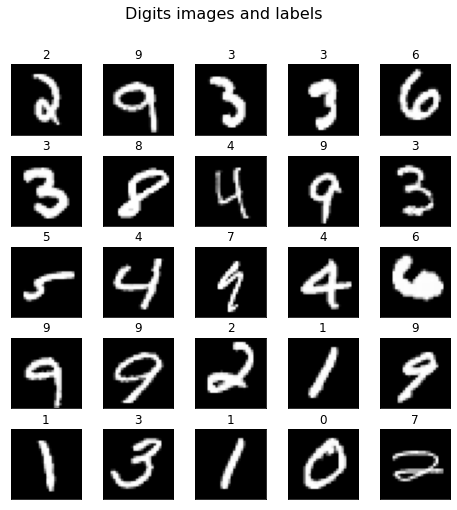

In [20]:
y_test = cnn1.predict(test_array)
y_test = np.array(pd.DataFrame(y_test).idxmax(axis=1))
fig, ax = plt.subplots(5, 5, figsize=(8, 8))
fig.suptitle('Digits images and labels', fontsize=16)
ax = ax.ravel()
for i in range(25):
    sample_n = random.randint(0, test.shape[0])
    ax[i].imshow(np.array(test_df.iloc[sample_n]).reshape(28, 28), cmap='Greys_r')
    ax[i].get_xaxis().set_visible(False)
    ax[i].get_yaxis().set_visible(False)
    ax[i].set_title(y_test[sample_n], fontsize = 12)

plt.subplots_adjust(hspace=0.3)
fig.show()

In [21]:
pred = cnn1.predict(x_train_array)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_train=np.argmax(y_train, axis=1)
pred = np.array(pd.DataFrame(pred).idxmax(axis=1))

In [23]:
print(classification_report(y_train, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4132
           1       0.97      1.00      0.98      4684
           2       1.00      0.95      0.97      4177
           3       0.98      0.99      0.99      4351
           4       0.99      0.98      0.99      4072
           5       0.98      0.99      0.99      3795
           6       0.99      0.99      0.99      4137
           7       0.94      1.00      0.97      4401
           8       1.00      0.95      0.97      4063
           9       0.98      0.97      0.98      4188

    accuracy                           0.98     42000
   macro avg       0.98      0.98      0.98     42000
weighted avg       0.98      0.98      0.98     42000



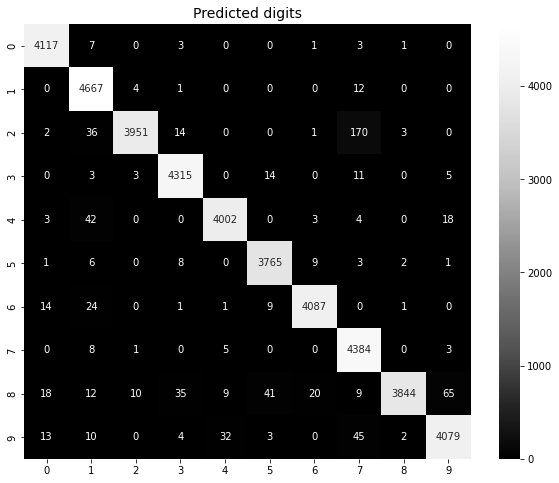

In [24]:
plt.figure(figsize=(10,8))
plt.title('Predicted digits', size=14)
sns.heatmap(confusion_matrix(y_train, pred), cmap='Greys_r', annot=True, fmt = '.0f')
plt.show()

In [25]:
df_submission = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')
df_submission['Label']=y_test
df_submission.to_csv('submission.csv',index=False)

In [26]:
df_submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


## <p style="background-color:#AFB6B2;color:black;font-size:20px;text-align:center;border-radius:10px 10px;"> Hyperparameter tuning with Kerastuner 🔽</p>

<font size="4">Hyperparameters are the different factors that influence the machine learning model's pace of learning. A model's performance is controlled via hyperparameters. Keras Tuner can help you find the ideal hyperparameter values for your models. The diagram depicts how a Keras tuner works.</font>
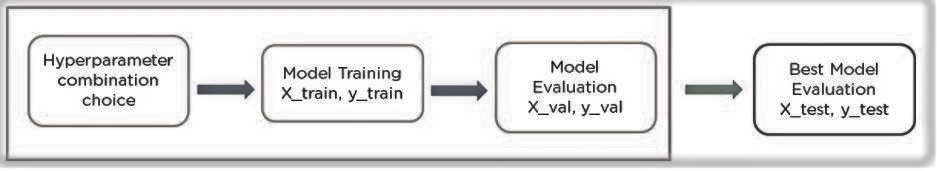

In [27]:
!pip install keras-tuner
import tensorflow as tf
from keras.utils import np_utils
from tensorflow import keras
from tensorflow.keras import layers
from kerastuner.tuners import RandomSearch
import kerastuner as kt

In [28]:
def build_model(hp):
    # create model object
    model = keras.Sequential([
    #adding first convolutional layer    
    keras.layers.Conv2D(
        #adding filter 
        filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
        # adding filter size or kernel size
        kernel_size=hp.Choice('conv_1_kernel', values = [3,5]),
        #activation function
        activation='relu',
        input_shape=(28,28,1)),
    
    # adding second convolutional layer 
    keras.layers.Conv2D(
        #adding filter 
        filters=hp.Int('conv_2_filter', min_value=32, max_value=64, step=16),
        #adding filter size or kernel size
        kernel_size=hp.Choice('conv_2_kernel', values = [3,5]),
        #activation function
        activation='relu'
    ),
   
    #keras.layers.Dropout(0.25),
    # adding flatten layer    
    keras.layers.Flatten(),
    # adding dense layer    
    keras.layers.Dense(
        units=hp.Int('dense_1_units', min_value=32, max_value=128, step=16),
        activation='relu'
    ),
    # output layer    
    keras.layers.Dense(10, activation='softmax')
    ])
    #compilation of model
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3])),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return model

In [29]:
#importing random search
from kerastuner import RandomSearch
#creating randomsearch object
tuner = RandomSearch(build_model,
                    objective='val_accuracy',
                    max_trials = 7)
# search best parameter
tuner.search(x_train_array,y_train,epochs=5,validation_split=0.1)

Trial 7 Complete [00h 00m 20s]
val_accuracy: 0.9866666793823242

Best val_accuracy So Far: 0.9885714054107666
Total elapsed time: 00h 04m 14s


In [30]:
model=tuner.get_best_models(num_models=1)[0]
#summary of best model
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 24, 24, 96)        2496      
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 20, 20, 48)        115248    
_________________________________________________________________
flatten (Flatten)            (None, 19200)             0         
_________________________________________________________________
dense (Dense)                (None, 32)                614432    
_________________________________________________________________
dense_1 (Dense)              (None, 10)                330       
Total params: 732,506
Trainable params: 732,506
Non-trainable params: 0
_________________________________________________________________


In [31]:
model.fit(x_train_array,y_train,
          epochs=100,
          validation_split=0.1,
          initial_epoch=3)

Epoch 4/100
1182/1182 [==============================] - 5s 4ms/step - loss: 0.0136 - accuracy: 0.9955 - val_loss: 0.0406 - val_accuracy: 0.9888
Epoch 5/100
1182/1182 [==============================] - 4s 3ms/step - loss: 0.0097 - accuracy: 0.9971 - val_loss: 0.0739 - val_accuracy: 0.9829
Epoch 6/100
1182/1182 [==============================] - 4s 4ms/step - loss: 0.0106 - accuracy: 0.9967 - val_loss: 0.0558 - val_accuracy: 0.9862
Epoch 7/100
1182/1182 [==============================] - 5s 4ms/step - loss: 0.0094 - accuracy: 0.9968 - val_loss: 0.0604 - val_accuracy: 0.9881
Epoch 8/100
1182/1182 [==============================] - 4s 4ms/step - loss: 0.0047 - accuracy: 0.9985 - val_loss: 0.0701 - val_accuracy: 0.9843
Epoch 9/100
1182/1182 [==============================] - 4s 4ms/step - loss: 0.0071 - accuracy: 0.9979 - val_loss: 0.0614 - val_accuracy: 0.9857
Epoch 10/100
1182/1182 [==============================] - 4s 4ms/step - loss: 0.0076 - accuracy: 0.9977 - val_loss: 0.0631 - val_a

In [32]:
predt = model.predict(x_train_array)
predt = np.array(pd.DataFrame(predt).idxmax(axis=1))

In [33]:
print(classification_report(y_train, predt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4132
           1       1.00      1.00      1.00      4684
           2       1.00      1.00      1.00      4177
           3       1.00      1.00      1.00      4351
           4       1.00      1.00      1.00      4072
           5       1.00      1.00      1.00      3795
           6       1.00      1.00      1.00      4137
           7       1.00      1.00      1.00      4401
           8       1.00      1.00      1.00      4063
           9       1.00      1.00      1.00      4188

    accuracy                           1.00     42000
   macro avg       1.00      1.00      1.00     42000
weighted avg       1.00      1.00      1.00     42000



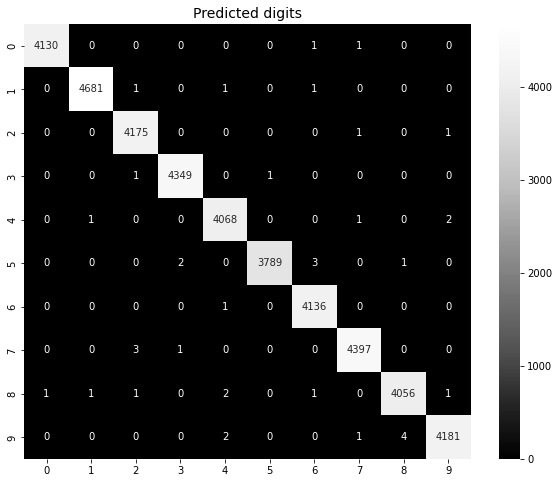

In [34]:
plt.figure(figsize=(10,8))
plt.title('Predicted digits', size=14)
sns.heatmap(confusion_matrix(y_train, predt), cmap='Greys_r', annot=True, fmt = '.0f')
plt.show()

In [35]:
y_test1 = model.predict(test_array)
y_test1 = np.array(pd.DataFrame(y_test1).idxmax(axis=1))

In [36]:
df_submission = pd.read_csv('/kaggle/input/digit-recognizer/sample_submission.csv')
df_submission['Label']=y_test
df_submission.to_csv('submission1.csv',index=False)

<center><p style="color:#AFB9B9;font-size:17px;border:2px solid black;border-radius:12px 10px;text-align:center;">
<b>Highly appreciate your questions or feedback related to this notebook.If you liked this Notebook, please do <span style="color:gold;">upvote</span>. THANK YOU <span style='font-size:22px;'>&#128522;</span></b> </p></center>